# Purchasing Cycle Comparison

The inventory replenishment team wants to compare the typical purchasing cycles associated with Produce and Alcohol.

## Load the data

Load the order history, prior purchases, product information, and department labels needed for the comparison.

In [20]:
import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = "../../data/shop"

orders = pd.read_csv(
    f"{DATA_DIR}/orders.csv",
    usecols=[
        "order_id",
        "user_id",
        "order_number",
        "days_since_prior_order",
    ],
)

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=[
        "order_id",
        "product_id",
    ],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=[
        "product_id",
        "department_id",
    ],
)

departments = pd.read_csv(
    f"{DATA_DIR}/departments.csv",
)

orders.head()

,order_id,user_id,order_number,days_since_prior_order
0,2539329,1,1,NaN
1,2398795,1,2,15.0
2,473747,1,3,21.0
3,2254736,1,4,29.0
4,431534,1,5,28.0


## Identify Produce and Alcohol orders

Map purchased products to departments and identify prior orders containing Produce or Alcohol.

In [21]:
department_orders = (
    order_products
    .merge(
        products,
        on="product_id",
    )
    .merge(
        departments,
        on="department_id",
    )
    .query(
        "department in ['produce', 'alcohol']"
    )
    [
        ["order_id", "department"]
    ]
    .drop_duplicates()
    .merge(
        orders,
        on="order_id",
    )
)


print(
    department_orders
    .groupby("department")["order_id"]
    .nunique()
)

department
alcohol      84689
produce    2409320
Name: order_id, dtype: int64


## Calculate purchasing cycles

Measure each department's purchasing cycle as the time between successive purchases from that department by the same shopper.

The order history is converted into a cumulative shopping timeline so that consecutive Produce and Alcohol purchases can be compared in days.

In [22]:
orders_timeline = (
    orders
    .sort_values(
        ["user_id", "order_number"]
    )
    .copy()
)

orders_timeline[
    "days_since_prior_order"
] = (
    orders_timeline[
        "days_since_prior_order"
    ]
    .fillna(0)
)

orders_timeline["shopping_day"] = (
    orders_timeline
    .groupby("user_id")
    ["days_since_prior_order"]
    .cumsum()
)


department_history = (
    department_orders[
        [
            "order_id",
            "department",
        ]
    ]
    .merge(
        orders_timeline[
            [
                "order_id",
                "user_id",
                "order_number",
                "shopping_day",
            ]
        ],
        on="order_id",
    )
    .sort_values(
        [
            "department",
            "user_id",
            "order_number",
        ]
    )
)


department_history[
    "department_cycle_days"
] = (
    department_history
    .groupby(
        [
            "department",
            "user_id",
        ]
    )["shopping_day"]
    .diff()
)


department_cycles = (
    department_history
    .dropna(
        subset=["department_cycle_days"]
    )
)


print(
    department_cycles[
        [
            "department",
            "user_id",
            "order_number",
            "department_cycle_days",
        ]
    ]
    .head()
)

        department  user_id  order_number  department_cycle_days
69072      alcohol        4             4                   36.0
2337489    alcohol       14             2                   30.0
996412     alcohol       14             3                    2.0
1010282    alcohol       14             4                   20.0
1233513    alcohol       14             5                   30.0


## Compare the departments

Calculate the average purchase cycle for each department and identify which department has the shorter cycle.

In [23]:
summary = (
    department_cycles
    .groupby(
        "department",
        as_index=False,
    )
    .agg(
        cycle_count=(
            "department_cycle_days",
            "count",
        ),
        typical_cycle_days=(
            "department_cycle_days",
            "mean",
        ),
    )
)


print(
    summary.round(2)
)


cycles = summary.set_index(
    "department"
)["typical_cycle_days"]

alcohol_cycle = cycles["alcohol"]
produce_cycle = cycles["produce"]

shorter_group = (
    "Alcohol"
    if alcohol_cycle < produce_cycle
    else "Produce"
)


print(
    "\nShorter purchasing cycle:",
    shorter_group,
)

print(
    "Difference:",
    f"{abs(alcohol_cycle - produce_cycle):.2f} days",
)

  department  cycle_count  typical_cycle_days
0    alcohol        68891               15.99
1    produce      2216083               12.50

Shorter purchasing cycle: Produce
Difference: 3.48 days


## Visualize the purchasing cycles

Compare the calculated purchase cycles for Produce and Alcohol.

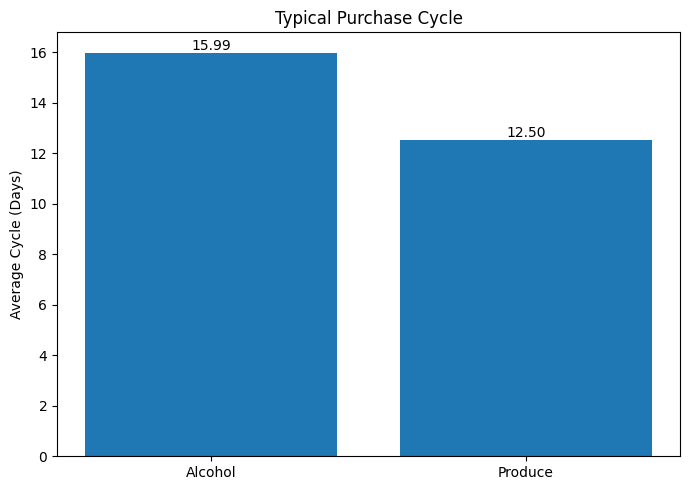

In [24]:
plot_data = summary.copy()

plot_data["department"] = (
    plot_data["department"]
    .str.title()
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)

bars = ax.bar(
    plot_data["department"],
    plot_data["typical_cycle_days"],
)

ax.set_title(
    "Typical Purchase Cycle"
)

ax.set_ylabel(
    "Average Cycle (Days)"
)


for bar, value in zip(
    bars,
    plot_data["typical_cycle_days"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()

## Visualize the purchasing cycles

Compare the typical purchasing cycles calculated for Produce and Alcohol.

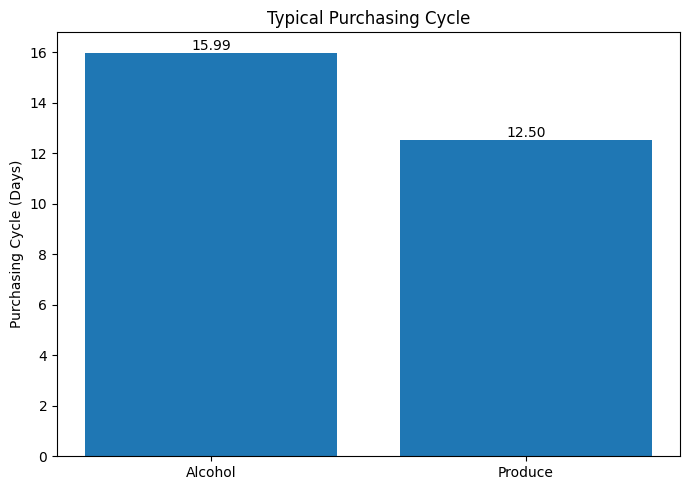

In [25]:
plot_data = summary.copy()

plot_data["department"] = (
    plot_data["department"]
    .str.title()
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)

bars = ax.bar(
    plot_data["department"],
    plot_data["typical_cycle_days"],
)

ax.set_title(
    "Typical Purchasing Cycle"
)

ax.set_ylabel(
    "Purchasing Cycle (Days)"
)

for bar, value in zip(
    bars,
    plot_data["typical_cycle_days"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Conclusion

Produce has the shorter typical purchase cycle, averaging **12.50 days** between successive Produce purchases compared with **15.99 days** between successive Alcohol purchases.

Produce therefore shows the faster purchasing cycle of the two departments.